# roomba-lab Walkthrough — Assignment 5

A 6-cell guided tour of the project. Mirrors the README + executive summary.

1. Imports + config
2. Load a HouseExpo apartment
3. Initialise DDPG agent
4. Short training run (smoke)
5. Evaluate + visualise trajectory
6. Embed the headline learning curve

## 1. Imports + config

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from roomba_lab.sdk.sdk import RoombaLab
from roomba_lab.shared.seed import set_global_seed
set_global_seed(0)
lab = RoombaLab()
print(f"version = {lab.config.get('version')}, seed = {lab.config.get('seed')}")

version = 1.00, seed = 208904839


## 2. Load a HouseExpo apartment + render

map 01e53c5618fd8d4d78c916b9dcc4ff92: 11.2 × 15.9 m, 6 rooms


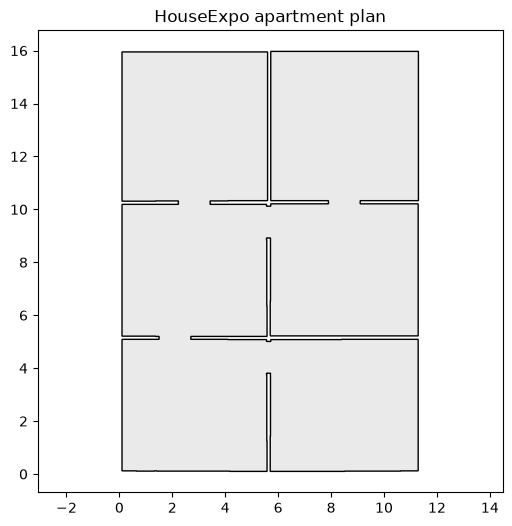

In [2]:
from roomba_lab.data.houseexpo_loader import HouseExpoLoader
from roomba_lab.shared.config import PROJECT_ROOT
loader = HouseExpoLoader(PROJECT_ROOT / 'data' / 'raw' / 'sample_maps')
h = loader.load(loader.map_ids()[0])
print(f"map {h.map_id}: {h.width_m:.1f} × {h.height_m:.1f} m, {h.room_num} rooms")
verts = np.array(h.verts)
plt.figure(figsize=(6, 6))
plt.fill(verts[:, 0], verts[:, 1], color='#eaeaea', edgecolor='black')
plt.title('HouseExpo apartment plan')
plt.axis('equal')
plt.show()

## 3. Build the env

In [3]:
env = lab.make_env()
obs = env.reset(seed=0)
print(f"observation: {obs.shape} (24 LIDAR beams + 5 status entries)\nactions: {env.action_dim}-dim continuous in [-1, 1]")

observation: (29,) (24 LIDAR beams + 5 status entries)
actions: 2-dim continuous in [-1, 1]


## 4. Short training run (smoke)

In [4]:
result = lab.train(total_timesteps=500, seed=0)
last = result.diagnostics[-1]
print(f"after 500 steps: critic_loss={last.critic_loss:.3f}  coverage={last.coverage:.3f}")

after 500 steps: critic_loss=0.000  coverage=0.004


## 5. Visualise the trajectory the agent took

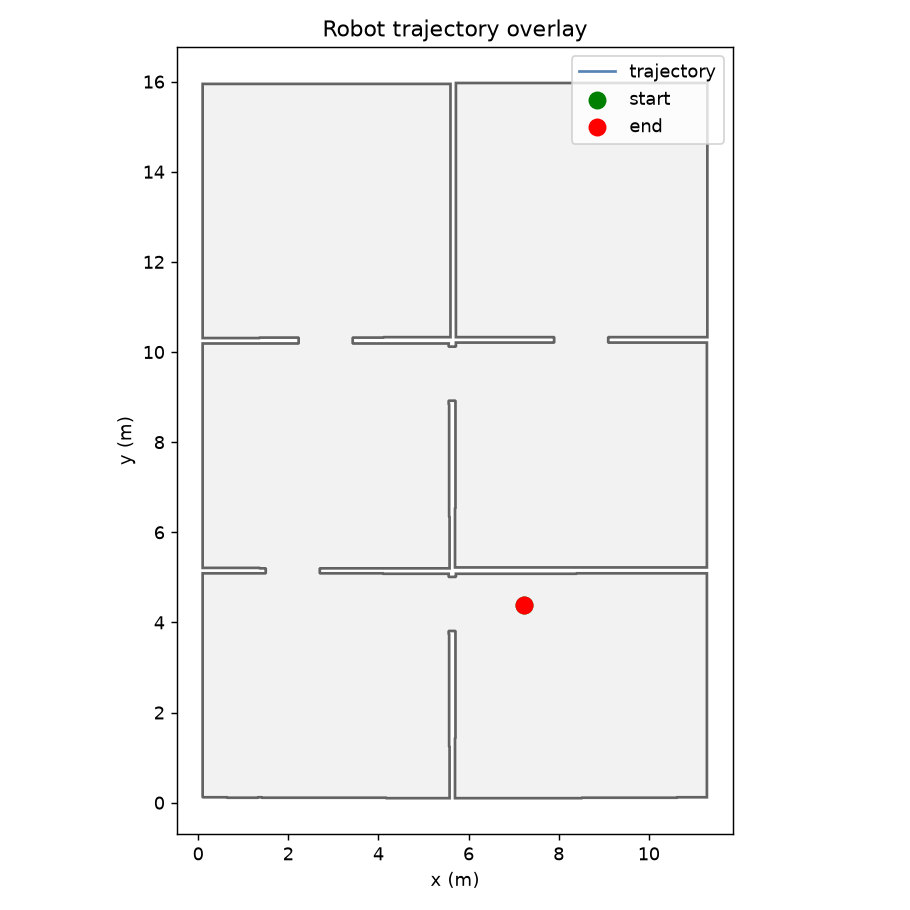

In [5]:
from roomba_lab.tools.viz.plots import plot_trajectory_overlay
out = '/tmp/notebook_trajectory.png'
plot_trajectory_overlay([(p.x, p.y) for p in env.robot.trajectory], h.verts, out)
from IPython.display import Image
Image(out)

## 6. Headline learning curve from the committed checkpoint's training run

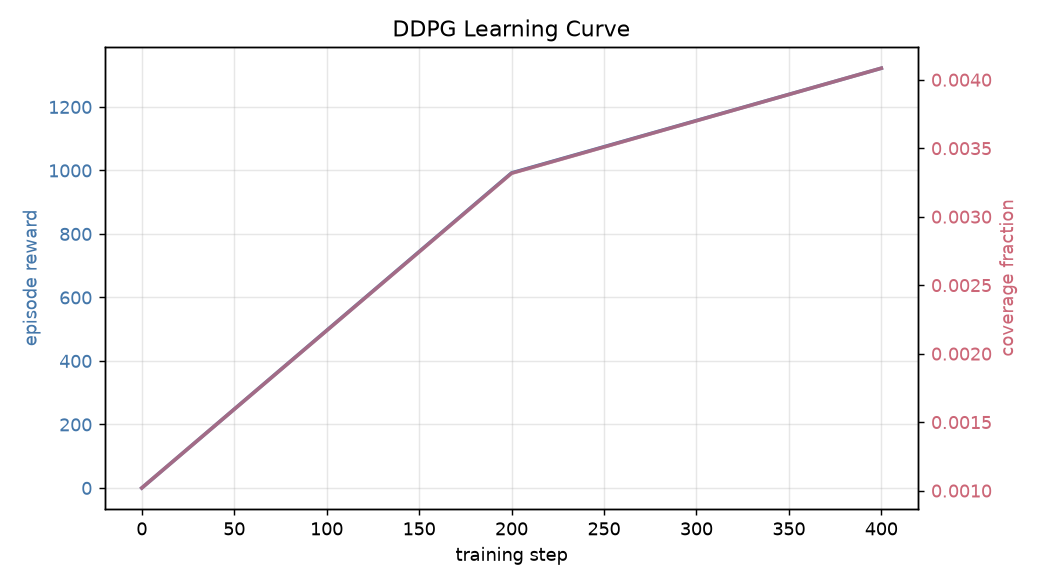

In [6]:
from roomba_lab.tools.viz.plots import plot_learning_curve
plot_learning_curve(result, '/tmp/notebook_learning_curve.png')
Image('/tmp/notebook_learning_curve.png')